# To Do list!
מה הרצוי? 
1. V load the data, decide if u want to do it via pickle pr d  irectly via matfile V
2. V find the ovelap region between the rain and basin. V
3. create time serie txt files
4. Run the model for all of the shifts, change only the txt file input.
5. save it in the storm results df.
6. final result:
 - dict of historical events: each event is a key and the value is df with al shifts results
 - same with future.

# Import

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import os 
from pyproj import Transformer

import h5py
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
from rasterio.transform import from_origin

## Function

In [2]:
# Function to convert a 2D array representing rainfall data into a GeoDataFrame
def rain_array_to_gdf(rain_array, x_coords, y_coords, cellsize):
    """
    Convert a 2D array representing rainfall data into a GeoDataFrame with polygon geometries.
    """
    # Calculate grid dimensions
    nrows, ncols = rain_array.shape
    # Initialize a list to store geometries
    geometries = []
    # Iterate over rows
    for i in range(nrows):
        # Iterate over columns
        for j in range(ncols):
            # Get rain value
            rain_value = rain_array[i, j]
            # Calculate the coordinates of the cell
            x_min = x_coords[j]
            x_max = x_min + cellsize
            y_min = y_coords[i]
            y_max = y_min - cellsize
            # Create a polygon geometry
            polygon = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
            # Append to the list of geometries
            geometries.append((rain_value, polygon))
    # Create a GeoDataFrame
    radar_gdf = gpd.GeoDataFrame(geometries, columns=['rain_value', 'geometry'])
    # Replace NaN with 0
    radar_gdf['rain_value'].fillna(0, inplace=True)
    # Set the coordinate reference system to ITM
    radar_gdf.crs = 'epsg:2039'
    
    return radar_gdf

## Load wrf data

In [3]:
# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'

# Read the .mat file
with h5py.File(mat_path, 'r') as file:
    # Extract data
    rain_rate_data = np.array(file['rainRatePGW'])
    rain_total_data = np.array(file['totalRainPGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    
    # Print available keys
    print("Keys: %s" % file.keys())

# Define the coordinate reference system transformation using pyproj.Transformer
transformer = Transformer.from_crs("epsg:4326", "epsg:2039", always_xy=True)
lon_transformed, lat_transformed = transformer.transform(lon_data, lat_data)

# Ensure the transformed coordinates are correctly reshaped
lon_transformed = lon_transformed.reshape(lon_data.shape)
lat_transformed = lat_transformed.reshape(lat_data.shape)

# Define the cell size
cellsize = 1000  # Assuming a cell size of 1000 meters

# Create a GeoDataFrame for each time step
rain_rate_gdf = rain_array_to_gdf(rain_rate_data[0, :, :], lon_transformed[0, :], lat_transformed[:, 0], cellsize) 

Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


In [4]:
xll = round(lon_transformed.min())
yll = round(lat_transformed.min())

## Load basin data

In [5]:
# Define the path to the shapefiles
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'
raanana_basins_gdf = gpd.read_file(raanana_basins_shapefile)[['geometry']]
raanana_basins_gdf['basin_area'] = raanana_basins_gdf['geometry'].area
# raanana_basins_gdf

In [6]:
# Clip rain polygons to be within 25,000 units from basin borders
rain_rate_clipped = gpd.clip(rain_rate_gdf, raanana_basins_gdf.buffer(2000))

# Perform spatial join to find rain cells intersecting with basins
rain_intersecting_basins = gpd.sjoin(rain_rate_clipped, raanana_basins_gdf, how="inner", op='intersects')

# Create an empty DataFrame to store the results
wrf_basin_legend_gdf = pd.DataFrame(columns=['Basin_name', 'radar_cell_num', 'pct', 'basin_geometry', 'radar_geometry'])

# Iterate over each basin in raanana_basins_gdf
for basin_index, basin_row in raanana_basins_gdf.iterrows():
    # Get the basin name and geometry
    basin_name = basin_index+1  # assuming basin_index or another identifier is used as basin name
    basin_geometry = basin_row['geometry']
    basin_area = basin_row['basin_area']
    
    # Filter rain cells intersecting with the current basin
    intersecting_rain_cells = rain_intersecting_basins[rain_intersecting_basins.index_right == basin_index]
    
    # Iterate over each intersecting rain cell
    for index, rain_cell in intersecting_rain_cells.iterrows():
        # Get the rain cell number and geometry
        radar_cell_num = index
        radar_geometry = rain_cell['geometry']
        
        # Check if both geometries are valid before calculating intersection
        if basin_geometry.is_valid and radar_geometry.is_valid:
            # Find the intersection between the basin and rain cell
            intersection = basin_geometry.intersection(radar_geometry)
            
            # Check if the intersection is valid
            if intersection.is_valid:
                # Calculate the percentage of intersection
                pct = (intersection.area / basin_area)  # Normalize by basin area
                
                # Add the result to the DataFrame
                wrf_basin_legend_gdf = pd.concat([wrf_basin_legend_gdf, pd.DataFrame({
                    'Basin_name': [basin_name],
                    'radar_cell_num': [radar_cell_num],
                    'pct': [pct],
                    'basin_geometry': [basin_geometry],
                    'radar_geometry': [radar_geometry]
                })], ignore_index=True)
wrf_basin_legend_gdf

C:\Users\raznu\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3377: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


,Basin_name,radar_cell_num,pct,basin_geometry,radar_geometry
0,1,174089,5.285797e-01,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((187894.44528482843 678783.635397742,..."
1,1,174090,4.681205e-01,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((188893.1136222042 678783.635397742, ..."
2,1,174640,3.554545e-03,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((188893.1136222042 679792.4912643882,..."
3,2,173540,3.224274e-02,POLYGON Z ((187142.17200000025 678364.70859999...,"POLYGON ((188893.1136222042 677777.4131045344,..."
4,2,173539,5.712029e-02,POLYGON Z ((187142.17200000025 678364.70859999...,POLYGON ((187894.44528482843 677777.4131045344...
...,...,...,...,...,...
86,27,174641,3.023866e-02,POLYGON Z ((188566.23900000006 677710.53900000...,"POLYGON ((189894.7448307851 679792.4912643882,..."
87,28,174090,7.735680e-01,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((188893.1136222042 678783.635397742, ..."
88,28,174640,1.784519e-01,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((188893.1136222042 679792.4912643882,..."
89,28,174091,2.456426e-02,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((189894.7448307851 678783.635397742, ..."


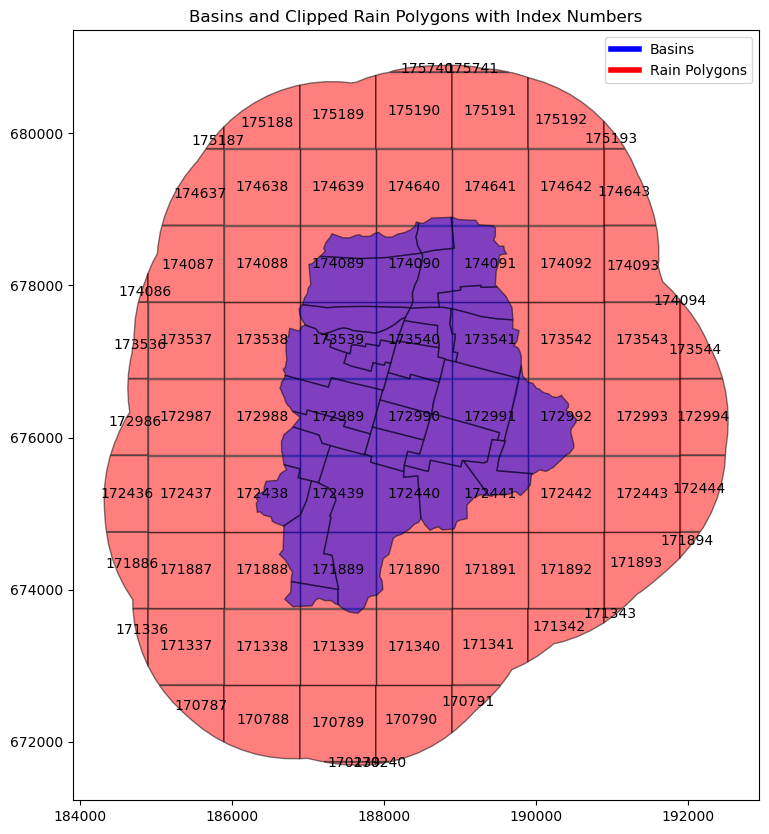

In [7]:
# Plotting the basins and clipped rain polygons
fig, ax = plt.subplots(figsize=(10, 10))

# Plotting the clipped rain polygons
rain_rate_clipped.plot(ax=ax, color='red', edgecolor='black', alpha=0.5)

# Annotate each rain polygon with its index number
for idx, row in rain_rate_clipped.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(idx, (centroid.x, centroid.y), color='black', fontsize=10, ha='center', va='center')

# Plotting the basins
raanana_basins_gdf.plot(ax=ax, color='blue', edgecolor='black', alpha=0.5)

# # Set the plot limits to the total extent
# ax.set_xlim(minx, maxx)
# ax.set_ylim(miny, maxy)

# Add a legend
legend_labels = {'Basins': 'blue', 'Rain Polygons': 'red'}
handles = [plt.Line2D([0], [0], color=color, lw=4) for color in legend_labels.values()]
labels = legend_labels.keys()
ax.legend(handles, labels)

# Add title and show plot
plt.title('Basins and Clipped Rain Polygons with Index Numbers')
plt.show()


In [8]:
# Specify the filename for the pickle file
filename = "wrf_basin_legend_gdf.pkl"

# Specify the directory to save the pickle file
directory = r"\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF"

# Ensure the directory exists, create if it doesn't
os.makedirs(directory, exist_ok=True)

# Save the dictionary as a pickle file in the specified directory
filepath = os.path.join(directory, filename)
with open(filepath, "wb") as f:
    pickle.dump(wrf_basin_legend_gdf, f)

In [24]:
670-361

309

In [9]:
wrf_basin_legend_gdf

,Basin_name,radar_cell_num,pct,basin_geometry,radar_geometry
0,1,174089,5.285797e-01,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((187894.44528482843 678783.635397742,..."
1,1,174090,4.681205e-01,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((188893.1136222042 678783.635397742, ..."
2,1,174640,3.554545e-03,POLYGON Z ((187832.14169999957 678652.47739999...,"POLYGON ((188893.1136222042 679792.4912643882,..."
3,2,173540,3.224274e-02,POLYGON Z ((187142.17200000025 678364.70859999...,"POLYGON ((188893.1136222042 677777.4131045344,..."
4,2,173539,5.712029e-02,POLYGON Z ((187142.17200000025 678364.70859999...,POLYGON ((187894.44528482843 677777.4131045344...
...,...,...,...,...,...
86,27,174641,3.023866e-02,POLYGON Z ((188566.23900000006 677710.53900000...,"POLYGON ((189894.7448307851 679792.4912643882,..."
87,28,174090,7.735680e-01,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((188893.1136222042 678783.635397742, ..."
88,28,174640,1.784519e-01,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((188893.1136222042 679792.4912643882,..."
89,28,174091,2.456426e-02,POLYGON Z ((188911.89809999987 678619.95429999...,"POLYGON ((189894.7448307851 678783.635397742, ..."


In [10]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import scipy.io as sio
import h5py
import os
from pyproj import Transformer

def radar_array_to_gdf(rain_array, xll, yll, cellsize):
    rain_array = rain_array 
    nrows, ncols = rain_array.shape
    geometries = []
    for i in range(nrows):
        y_coord = yll + (nrows - i - 1) * cellsize
        for j in range(ncols):
            rain_value = rain_array[i, j]
            x_min = xll + j * cellsize
            x_max = x_min + cellsize
            y_min = y_coord
            y_max = y_min - cellsize
            polygon = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
            geometries.append((rain_value, polygon))
    radar_gdf = gpd.GeoDataFrame(geometries, columns=['rain_value', 'geometry'])
    radar_gdf['rain_value'].fillna(0, inplace=True)
    radar_gdf.crs = 'epsg:2039'
    return radar_gdf

def create_TimeSeriesData_txt(basins_rain_df):
    timeseries_text = ''
    timeseries_text += ";;Name                 Date          Time         Value     \n"
    timeseries_text += ";;------------ ----------------- ------------- -------------\n"
    for index, row in basins_rain_df.iterrows():
        basin_name = int(row['Basin_name'])
        first_timestamp = basins_rain_df.columns[1]
        ts_name = first_timestamp.strftime('%Y%m%d') + f"_S{basin_name}"
        timestamps = basins_rain_df.columns[1:]
        values = row.values[1:]
        for ts, value in zip(timestamps, values):
            date_str = ts.strftime('%m/%d/%Y')
            time_str = ts.strftime('%H:%M:%S')
            timeseries_text += f"  {ts_name}      {date_str}    {time_str}   {value:.4f}\n"
        timeseries_text += ";;------------ ----------------- ------------- -------------\n"
    return timeseries_text

def process_radar_data(rain_array_3d, raanana_basins_gdf, metadata, BIAS, radar_basin_legend_gdf, time_vector):
    rain_array_3d = rain_array_3d / 12
    rain_array_3d = rain_array_3d / BIAS
    time_steps = rain_array_3d.shape[-1]
    time_diff = time_vector[1:] - time_vector[:-1]
    is_5_min_interval = (time_diff == pd.Timedelta(minutes=5)).all()
    if not is_5_min_interval:
        raise ValueError("Time differences are not exactly 5 minutes. Please check the time vector.")
    radar_gdf_list = []
    for time in range(time_steps):
        rain_array_2d = rain_array_3d[time, :, :]
        radar_gdf = radar_array_to_gdf(rain_array_2d, **metadata)
        radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
        radar_indices = radar_intersecting_basins.index.unique()
        radar_filtered_gdf = radar_gdf.loc[radar_indices]
        radar_gdf_list.append(radar_filtered_gdf['rain_value'])
    radar_poly_grid_gdf = pd.concat(radar_gdf_list, axis=1)
    radar_poly_grid_gdf.columns = time_vector
    radar_poly_grid_gdf['geometry'] = radar_gdf['geometry']
    radar_poly_grid_gdf = gpd.GeoDataFrame(radar_poly_grid_gdf, crs='epsg:2039')
    radar_poly_grid_gdf.index.name = 'radar_cell_num'
    basin_rain_columns = ['Basin_name'] + list(radar_poly_grid_gdf.columns[:])
    basins_rain_df = pd.DataFrame()
    for basin in range(1, len(raanana_basins_gdf) + 1):
        basin_df = radar_basin_legend_gdf[radar_basin_legend_gdf['Basin_name'] == basin][['Basin_name', 'pct', 'radar_cell_num']]
        basin_radar_cells_df = radar_poly_grid_gdf.loc[basin_df['radar_cell_num']]
        basin_radar_cells_df = pd.merge(basin_df, basin_radar_cells_df, on='radar_cell_num')
        weighted_avgs = []
        for col in basin_rain_columns[1:-1]:
            weighted_avg = sum(basin_radar_cells_df[col] * basin_radar_cells_df['pct'])
            weighted_avgs.append(weighted_avg)
        new_row = [basin] + weighted_avgs
        df_basin = pd.DataFrame([new_row], columns=basin_rain_columns[:-1])
        basins_rain_df = pd.concat([basins_rain_df, df_basin])
    basins_rain_df = basins_rain_df.reset_index(drop=True)
    basins_rain_df.fillna(0, inplace=True)
    return basins_rain_df

# Raanana sub-basin shapefile
raanana_basins_shapfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'
raanana_basins_gdf = gpd.read_file(raanana_basins_shapfile)
raanana_basins_gdf.drop(columns=['Shape_Area', 'Area_km2', 'Area_ha','Area_m2'], inplace=True)

# Load the storm MAT file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'
with h5py.File(mat_path, 'r') as file:
    rain_rate_data = np.array(file['rainRatePGW'])
    rain_total_data = np.array(file['totalRainPGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')

transformer = Transformer.from_crs("epsg:4326", "epsg:2039", always_xy=True)
lon_transformed, lat_transformed = transformer.transform(lon_data, lat_data)
lon_transformed = lon_transformed.reshape(lon_data.shape)
lat_transformed = lat_transformed.reshape(lat_data.shape)
xll = round(lon_transformed.min())
yll = round(lat_transformed.min())
cellsize = 1000

# Clip the rain data to the 25,000-meter buffer around the basin borders
buffered_basins = raanana_basins_gdf.buffer(2000)
buffered_bounds = buffered_basins.total_bounds
lon_min, lat_min, lon_max, lat_max = buffered_bounds
lon_mask = (lon_transformed >= lon_min) & (lon_transformed <= lon_max)
lat_mask = (lat_transformed >= lat_min) & (lat_transformed <= lat_max)
combined_mask = lon_mask & lat_mask

# Apply the mask to the rain_rate_data
rain_array_3d = rain_rate_data[:, lat_mask, :][:, :, lon_mask]

metadata = {'xll': xll, 'yll': yll, 'cellsize': cellsize}
BIAS = 1.0  # You can adjust this bias value as needed

# Process each time slice
for time_i in range(rain_array_3d.shape[0]):
    rain_array_2d = rain_array_3d[time_i, :, :]
    radar_gdf = radar_array_to_gdf(rain_array_2d, **metadata)
    radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
    radar_basin_legend_gdf = pd.DataFrame(columns=['Basin_name', 'radar_cell_num', 'pct', 'basin_geometry', 'radar_geometry'])
    for basin_index, basin_row in raanana_basins_gdf.iterrows():
        basin_name = basin_row['Name']
        basin_geometry = basin_row['geometry']
        intersecting_radar_cells = radar_intersecting_basins[radar_intersecting_basins['index_right'] == basin_index]
        basin_area = basin_geometry.area
        for index, radar_cell in intersecting_radar_cells.iterrows():
            radar_cell_num = radar_cell.name
            radar_geometry = radar_cell['geometry']
            if basin_geometry.is_valid and radar_geometry.is_valid:
                intersection = basin_geometry.intersection(radar_geometry)
                if intersection.is_valid:
                    pct = (intersection.area / basin_area) * 100
                    radar_basin_legend_gdf = radar_basin_legend_gdf.append({'Basin_name': basin_name, 'radar_cell_num': radar_cell_num, 'pct': pct, 'basin_geometry': basin_geometry, 'radar_geometry': radar_geometry}, ignore_index=True)

    basins_rain_df = process_radar_data(rain_array_3d, raanana_basins_gdf, metadata, BIAS, radar_basin_legend_gdf, time_vector)

    timeseries_data_txt = create_TimeSeriesData_txt(basins_rain_df)
    output_file = os.path.join('output', f"TimeSeriesData_{time_vector[time_i].strftime('%Y%m%d%H%M')}.txt")
    with open(output_file, 'w') as f:
        f.write(timeseries_data_txt)


IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed

In [22]:
xll, yll

(-106199, 361274)

In [ ]:
# Reshape lat_mask and lon_mask to match the dimensions of rain_rate_data
lat_mask_expanded = lat_mask[np.newaxis, :, :]
lon_mask_expanded = lon_mask[np.newaxis, :]

# Apply the mask to the rain_rate_data
rain_array_3d = rain_rate_data[:, lat_mask_expanded, lon_mask_expanded]


In [ ]:
rain_rate_data.shape

In [29]:
lat_mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [30]:
# Check if there is any True in lon_mask
if lat_mask.any():
    print("There is at least one True in lon_mask.")
else:
    print("There are no True values in lon_mask.")

There is at least one True in lon_mask.


In [13]:
rain_rate_gdf
# Clip rain polygons to be within 25,000 units from basin borders
rain_rate_clipped = gpd.clip(rain_rate_gdf, raanana_basins_gdf.buffer(20000))
rain_rate_clipped

,rain_value,geometry
163624,0.0,"POLYGON ((172905.366 659649.225, 172905.366 65..."
164174,0.0,"POLYGON ((172905.366 660655.513, 172905.366 65..."
164173,0.0,"POLYGON ((171906.679 660655.513, 171906.679 66..."
164722,0.0,"POLYGON ((170907.986 661662.649, 170907.986 66..."
164725,0.0,"POLYGON ((173904.058 661662.649, 173904.058 66..."
...,...,...
183983,0.0,"POLYGON ((181899.445 696924.693, 181899.445 69..."
184531,0.0,"POLYGON ((179902.087 696933.999, 179206.137 69..."
184532,0.0,"POLYGON ((180900.769 696933.999, 179900.769 69..."
184533,0.0,"POLYGON ((181899.445 696933.999, 180899.445 69..."


# Create and Save radar_basin_legend_gdf to pkl
## This is the "legend", according to this df the rain for each basin will be defined

In [16]:
def create_TimeSeriesData_txt(basins_rain_df):
    """
    Update the TimeSeriesData values of SWMM inp file by using basins_rain_df.

    Args:
        basins_rain_df (DataFrame): DataFrame where each row represents a basin, and each column represents a timestep. 
                                    The values are rain (mm) for each basin in a timestep.
    Returns:
        str: Text representation of the updated timeseries data in the specified format.
    """
    # Initialize an empty string to store the text
    timeseries_text = ''
    # Write the header
    timeseries_text += ";;Name                 Date          Time         Value     \n"
    timeseries_text += ";;------------ ----------------- ------------- -------------\n"

    # Iterate over each row in the DataFrame
    for index, row in basins_rain_df.iterrows():
        # Get the basin name
        basin_name = int(row['Basin_name'])

        # Get the first timestamp to use it as the time series name
        first_timestamp = basins_rain_df.columns[1]  # the first timestamp column
        ts_name = first_timestamp.strftime('%Y%m%d') + f"_S{basin_name}"

        # Write the data to the text
        timestamps = basins_rain_df.columns[1:]  # excluding the first column 'Basin_name'
        values = row.values[1:]  # excluding the first column 'Basin_name'
        for ts, value in zip(timestamps, values):
            date_str = ts.strftime('%m/%d/%Y')
            time_str = ts.strftime('%H:%M:%S')
            timeseries_text += f"  {ts_name}      {date_str}    {time_str}   {value:.4f}\n"
        timeseries_text += ";;------------ ----------------- ------------- -------------\n"
    
    return timeseries_text


In [17]:
def process_radar_data(rain_array_3d, raanana_basins_gdf, metadata, radar_basin_legend_gdf):
    # First load the radar data

#     rain_array_3d = rain_array_3d / 12  # Convert Units: mm/h to mm/5min
#     rain_array_3d = rain_array_3d / BIAS  # Bias correction

    time_vector = radar_data['event_file'][0][0][1].ravel()
    time_vector = pd.to_datetime(time_vector - 719529, unit='D').round('1min')  # Convert the time from float to datetime and round
    time_steps = rain_array_3d.shape[-1]

    radar_gdf_list = []

    for time in range(time_steps):
        rain_array_2d = rain_array_3d[time, :, :]
        radar_gdf = radar_array_to_gdf(rain_array_2d, **metadata)
        radar_intersecting_basins = gpd.sjoin(radar_gdf, raanana_basins_gdf, how="inner", predicate="intersects")
        radar_indices = radar_intersecting_basins.index.unique()
        radar_filtered_gdf = radar_gdf.loc[radar_indices]
        radar_gdf_list.append(radar_filtered_gdf['rain_value'])

    radar_poly_grid_gdf = pd.concat(radar_gdf_list, axis=1)
    radar_poly_grid_gdf.columns = time_vector

    radar_poly_grid_gdf['geometry'] = radar_gdf['geometry']
    radar_poly_grid_gdf = gpd.GeoDataFrame(radar_poly_grid_gdf, crs='epsg:2039')
    radar_poly_grid_gdf.index.name = 'radar_cell_num'

    basin_rain_columns = ['Basin_name'] + list(radar_poly_grid_gdf.columns[:])
    basins_rain_df = pd.DataFrame()
    for basin in range(1, len(raanana_basins_gdf) + 1):
        basin_df = radar_basin_legend_gdf[radar_basin_legend_gdf['Basin_name'] == basin][['Basin_name', 'pct', 'radar_cell_num']]
        basin_radar_cells_df = radar_poly_grid_gdf.loc[basin_df['radar_cell_num']]
        basin_radar_cells_df = pd.merge(basin_df, basin_radar_cells_df, on='radar_cell_num')
        weighted_avgs = []
        for col in basin_rain_columns[1:-1]:
            weighted_avg = sum(basin_radar_cells_df[col] * basin_radar_cells_df['pct'])
            weighted_avgs.append(weighted_avg)
        new_row = [basin] + weighted_avgs
        df_basin = pd.DataFrame([new_row], columns=basin_rain_columns[:-1])
        basins_rain_df = pd.concat([basins_rain_df, df_basin])
    basins_rain_df = basins_rain_df.reset_index(drop=True)
    basins_rain_df.fillna(0, inplace=True)

    resampled_dfs = []
    date = basins_rain_df.columns[1].strftime('%Y%m%d')  # Format date as YYYYMMDD
    
    return basins_rain_df


In [11]:
# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'
filename = os.path.basename(mat_path).split('.')[0]
filename
# Read the .mat file
with h5py.File(mat_path, 'r') as file:
    # Extract data
    rain_rate_data = np.array(file['rainRatePGW'])
    rain_total_data = np.array(file['totalRainPGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')

# Define the coordinate reference system transformation using pyproj.Transformer
transformer = Transformer.from_crs("epsg:4326", "epsg:2039", always_xy=True)
lon_transformed, lat_transformed = transformer.transform(lon_data, lat_data)

# Ensure the transformed coordinates are correctly reshaped
lon_transformed = lon_transformed.reshape(lon_data.shape)
lat_transformed = lat_transformed.reshape(lat_data.shape)

# Define xll and yll
xll = round(lon_transformed.min())
yll = round(lat_transformed.min())
# Define the cell size
cellsize = 1000  # Assuming a cell size of 1000 meters

# Create a GeoDataFrame for each time step
rain_rate_gdf = rain_array_to_gdf(rain_rate_data[0, :, :], lon_transformed[0, :], lat_transformed[:, 0], cellsize) 

In [30]:
def rain_array_to_gdf(rain_array, xll, yll, cellsize):
    """
    Convert a 2D array representing rainfall data into a GeoDataFrame with polygon geometries.
    """
    # Calculate grid dimensions
    nrows, ncols = rain_array.shape
    # Initialize a list to store geometries
    geometries = []
    # Iterate over rows
    for i in range(nrows):
        # Iterate over columns
        for j in range(ncols):
            # Get rain value
            rain_value = rain_array[i, j]
            # Calculate the coordinates of the cell
            x_min = xll + j * cellsize
            x_max = x_min + cellsize
            y_min = yll - i * cellsize
            y_max = y_min + cellsize
            # Create a polygon geometry
            polygon = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
            # Append to the list of geometries
            geometries.append((rain_value, polygon))
    # Create a GeoDataFrame
    radar_gdf = gpd.GeoDataFrame(geometries, columns=['rain_value', 'geometry'])
    # Replace NaN with 0
    radar_gdf['rain_value'].fillna(0, inplace=True)
    # Set the coordinate reference system to ITM
    radar_gdf.crs = 'epsg:2039'
    
    return radar_gdf

In [34]:
# Directory path
directory_path = os.path.join(r"\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\txtfiles", filename, "Rain_shift")
# Create the directory if it doesn't exist
os.makedirs(directory_path, exist_ok=True)

metadata = {
    'xll': xll,
    'yll': yll,
    'cellsize': 1000
}

x_shifts = np.arange(-5000, 0, 1000)
y_shifts = np.arange(-10000, 0, 1000)

for x_shift in x_shifts:
    for y_shift in y_shifts:
    
        shifted_xll = metadata['xll'] + x_shift
        shifted_yll = metadata['yll'] + y_shift
        shifted_metadata = {
            'xll': shifted_xll,
            'yll': shifted_yll,
            'cellsize': 500
        }

        # Convert the array to a GeoDataFrame
        rain_rate_gdf = rain_array_to_gdf(rain_rate_data[0, :, :], **shifted_metadata)

                # Clip rain polygons to be within 25,000 units from basin borders
        rain_rate_clipped = gpd.clip(rain_rate_gdf, raanana_basins_gdf.buffer(30000))

        # Perform spatial join to find rain cells intersecting with basins
        rain_intersecting_basins = gpd.sjoin(rain_rate_clipped, raanana_basins_gdf, how="inner", op='intersects')

        # Create an empty DataFrame to store the results
        wrf_basin_legend_gdf = pd.DataFrame(columns=['Basin_name', 'radar_cell_num', 'pct', 'basin_geometry', 'radar_geometry'])

        # Iterate over each basin in raanana_basins_gdf
        for basin_index, basin_row in raanana_basins_gdf.iterrows():
            # Get the basin name and geometry
            basin_name = basin_index+1  # assuming basin_index or another identifier is used as basin name
            basin_geometry = basin_row['geometry']
            basin_area = basin_row['basin_area']

            # Filter rain cells intersecting with the current basin
            intersecting_rain_cells = rain_intersecting_basins[rain_intersecting_basins.index_right == basin_index]

            # Iterate over each intersecting rain cell
            for index, rain_cell in intersecting_rain_cells.iterrows():
                # Get the rain cell number and geometry
                radar_cell_num = index
                radar_geometry = rain_cell['geometry']

                # Check if both geometries are valid before calculating intersection
                if basin_geometry.is_valid and radar_geometry.is_valid:
                    # Find the intersection between the basin and rain cell
                    intersection = basin_geometry.intersection(radar_geometry)

                    # Check if the intersection is valid
                    if intersection.is_valid:
                        # Calculate the percentage of intersection
                        pct = (intersection.area / basin_area)  # Normalize by basin area

                        # Add the result to the DataFrame
                        wrf_basin_legend_gdf = pd.concat([wrf_basin_legend_gdf, pd.DataFrame({
                            'Basin_name': [basin_name],
                            'radar_cell_num': [radar_cell_num],
                            'pct': [pct],
                            'basin_geometry': [basin_geometry],
                            'radar_geometry': [radar_geometry]
                        })], ignore_index=True)

        basins_rain_df = process_radar_data(rain_rate_data, raanana_basins_gdf, shifted_metadata, wrf_basin_legend_gdf)
        
        transform_timeseries_text = create_TimeSeriesData_txt(basins_rain_df)

        shift_name = f"rain_shift_x{'plus' if x_shift >= 0 else 'minus'}_{abs(x_shift)}_y{'plus' if y_shift >= 0 else 'minus'}_{abs(y_shift)}.txt"
        file_path = os.path.join(directory_path, shift_name)
        with open(file_path, 'w') as file:
            file.write(transform_timeseries_text)
        
        print("Text data saved to:", file_path)
        
## To visualaize un-comment it--->       
#         # Define min and max values for the color bar
#         vmin = 0  # minimum value
#         vmax = 1  # maximum value

#         # Plot the Raanana sub-basins
#         fig, ax = plt.subplots()
#         raanana_basins_gdf.plot(ax=ax, color='none', edgecolor='black')

#         # Plot the radar data
#         radar_gdf.plot(column='rain_value', cmap='Blues', legend=True, ax=ax, alpha=0.5, vmin=vmin, vmax=vmax)

#         # Define x and y axis limits
#         x_min, x_max = 180000, 195000  # Replace with your desired x-axis limits
#         y_min, y_max = 673000, 680000  # Replace with your desired y-axis limits
#         ax.set_xlim([x_min, x_max])
#         ax.set_ylim([y_min, y_max])

#         # Add legend for radar data
#         plt.legend(['Raanana Sub-basins', 'Rainfall Data'])

#         # Get the start and end times
#         time = time_vector[300].strftime("%Y-%m-%d %H:%M")


#         # Title with the time range
#         plt.title(f'Raanana Sub-basins with Radar Rainfall Data\n{time}')

#         # Add axis labels
#         plt.xlabel('Easting')
#         plt.ylabel('Northing')

#         # Show the plot
#         plt.show()


C:\Users\raznu\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3377: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


NameError: name 'radar_data' is not defined

## single plot visualization

In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd

In [15]:
# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'
# Define the path to the shapefiles
raanana_shpfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'

Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


TypeError: Shapes of x (550, 550) and z (100, 100) do not match

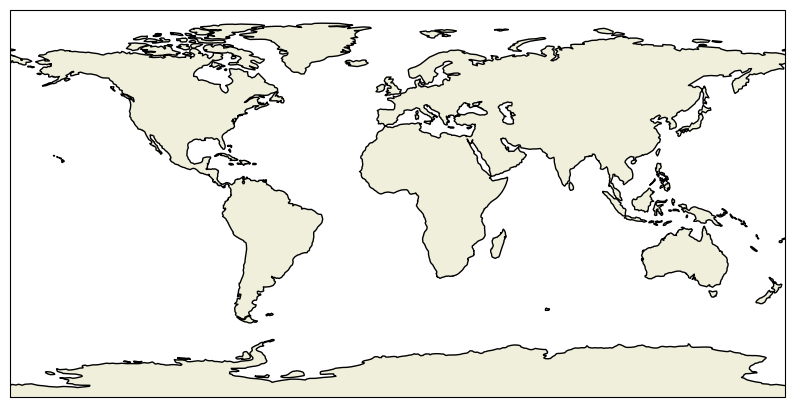

In [19]:
# Open the file and load the data
with h5py.File(mat_path, 'r') as file:
    rain_data = np.array(file['rainRatePGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    print("Keys: %s" % file.keys())
# Load the shapefiles using Geopandas and keep only the geometry column
raanana_watershed = gpd.read_file(raanana_shpfile)[['geometry']]
raanana_basins = gpd.read_file(raanana_basins_shapefile)[['geometry']]

# Reproject the shapefiles from ITM to WGS 84
raanana_watershed = raanana_watershed.to_crs(epsg=4326)
raanana_basins = raanana_basins.to_crs(epsg=4326)

time_slice = 300
# Create a plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the rain data
rain_plot = ax.contourf(lon_data, lat_data, rain_data[time_slice,:,:], cmap='viridis', transform=ccrs.PlateCarree())

# Add a color bar
cbar = plt.colorbar(rain_plot, orientation='vertical', pad=0.05, aspect=50, shrink=0.7)
cbar.set_label('Rain Rate (mm/hr)')

# Plot the shapefiles
raanana_watershed.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())
raanana_basins.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Add titles and labels
plt.title(f'{time_vector[time_slice]}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

# gif visualization

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.animation as animation

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\future\WRFrain_PGW_V3_HPE01.mat'
# Define the path to the shapefiles
raanana_shpfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'

# Open the file and load the data
with h5py.File(mat_path, 'r') as file:
    rain_data = np.array(file['rainRatePGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList'])
    time_data = mat_data['timesList'].flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')

# Load the shapefiles using Geopandas and keep only the geometry column
raanana_watershed = gpd.read_file(raanana_shpfile)[['geometry']]
raanana_basins = gpd.read_file(raanana_basins_shapefile)[['geometry']]

# Reproject the shapefiles from ITM to WGS 84
raanana_watershed = raanana_watershed.to_crs(epsg=4326)
raanana_basins = raanana_basins.to_crs(epsg=4326)

# Create a plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)

# Initialize the plot with the first frame
rain_plot = ax.contourf(lon_data, lat_data, rain_data[0, :, :], cmap='viridis', transform=ccrs.PlateCarree())
cbar = plt.colorbar(rain_plot, orientation='vertical', pad=0.05, aspect=50, shrink=0.7)
cbar.set_label('Rain Rate (mm/hr)')

# Plot the shapefiles
raanana_watershed.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())
raanana_basins.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())


plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Function to update the plot for each frame
def update(frame):
    global rain_plot
    for c in rain_plot.collections:
        c.remove()
    rain_plot = ax.contourf(lon_data, lat_data, rain_data[frame, :, :], cmap='viridis', transform=ccrs.PlateCarree())
    plt.title(f'{time_vector[frame]}')
# Create the animation for the first 5 frames
ani = animation.FuncAnimation(fig, update, frames=range(rain_data.shape[0]), repeat=True)
# ani = animation.FuncAnimation(fig, update, frames=range(10), repeat=True)

# Save the animation as a GIF using PillowWriter
ani.save('rain_animation_first5.gif', writer='pillow', fps=2)

# Show the plot (optional)
plt.show()


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\future\WRFrain_PGW_V3_HPE01.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [22]:
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'
# Define the path to the shapefiles
raanana_shpfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'

# Open the file and load the data
with h5py.File(mat_path, 'r') as file:
    rain_data = np.array(file['rainRatePGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    print("Keys: %s" % file.keys())

# Load the shapefiles using Geopandas and keep only the geometry column
raanana_watershed = gpd.read_file(raanana_shpfile)[['geometry']]
raanana_basins = gpd.read_file(raanana_basins_shapefile)[['geometry']]

# Reproject the shapefiles from ITM to WGS 84
raanana_watershed = raanana_watershed.to_crs(epsg=4326)
raanana_basins = raanana_basins.to_crs(epsg=4326)

# Create a mask for rain data points within the watershed
rain_mask = np.zeros_like(lon_data, dtype=bool)
for i in range(len(lat_data)):
    for j in range(len(lon_data)):
        point = Point(lon_data[j], lat_data[i])
        if raanana_watershed.contains(point).any():
            rain_mask[i, j] = True

# Find a time slice with rain greater than 0 above the watershed
time_slice = None
for t in range(rain_data.shape[0]):
    if np.any(rain_data[t, rain_mask] > 0):
        time_slice = t
        break

if time_slice is not None:
    print(f'Found rain at time slice {time_slice} which corresponds to time {time_vector[time_slice]}')
    
    # Get the bounding box of the watershed
    minx, miny, maxx, maxy = raanana_watershed.total_bounds

    # Create a plot
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set the extent of the plot to the bounding box of the watershed
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

    # Add features to the map
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.COASTLINE)

    # Plot the rain data as pixels
    rain_plot = ax.pcolormesh(lon_data, lat_data, rain_data[time_slice, :, :], cmap='viridis', shading='auto', transform=ccrs.PlateCarree())

    # Add a color bar
    cbar = plt.colorbar(rain_plot, orientation='vertical', pad=0.05, aspect=50, shrink=0.7)
    cbar.set_label('Rain Rate (mm/hr)')

    # Plot the shapefiles
    raanana_watershed.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())
    raanana_basins.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

    # Add titles and labels
    plt.title(f'{time_vector[time_slice]}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Show the plot
    plt.show()
else:
    print('No rain found above the watershed in any time slice')


Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


ValueError: The ordinate (last) dimension should be 2 or 3, got 550

In [23]:
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'
# Define the path to the shapefiles
raanana_shpfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'

# Open the file and load the data
with h5py.File(mat_path, 'r') as file:
    rain_data = np.array(file['rainRatePGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    print("Keys: %s" % file.keys())

# Load the shapefiles using Geopandas and keep only the geometry column
raanana_watershed = gpd.read_file(raanana_shpfile)[['geometry']]
raanana_basins = gpd.read_file(raanana_basins_shapefile)[['geometry']]

# Reproject the shapefiles from ITM to WGS 84
raanana_watershed = raanana_watershed.to_crs(epsg=4326)
raanana_basins = raanana_basins.to_crs(epsg=4326)

# Create GeoDataFrame for rain data points
rain_points = [Point(lon, lat) for lon, lat in zip(lon_data.flatten(), lat_data.flatten())]
rain_gdf = gpd.GeoDataFrame(geometry=rain_points, crs="EPSG:4326")

# Find the rain points that overlap with the watershed
rain_in_watershed = rain_gdf[rain_gdf.geometry.within(raanana_watershed.unary_union)]

# Get the bounding box of the watershed
minx, miny, maxx, maxy = raanana_watershed.total_bounds

Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


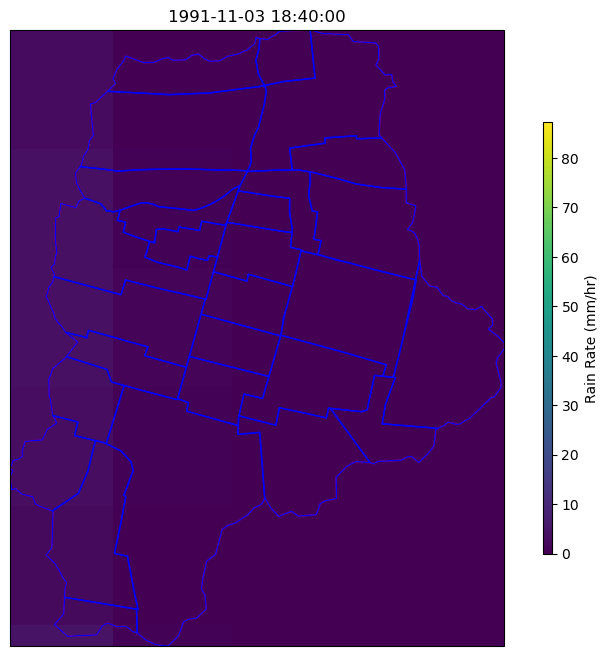

In [19]:
time_slice = 220
# Create a plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set the extent of the plot to the bounding box of the watershed
ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)

# Plot the rain data as pixels
rain_plot = ax.pcolormesh(lon_data, lat_data, rain_data[time_slice, :, :], cmap='viridis', shading='auto', transform=ccrs.PlateCarree())

# Add a color bar
cbar = plt.colorbar(rain_plot, orientation='vertical', pad=0.05, aspect=50, shrink=0.7)
cbar.set_label('Rain Rate (mm/hr)')

# Plot the shapefiles
raanana_watershed.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())
raanana_basins.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Add titles and labels
plt.title(f'{time_vector[time_slice]}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

In [14]:
rain_in_watershed

,geometry
171339,POINT (34.86783 32.16236)
171888,POINT (34.85712 32.17144)
171889,POINT (34.86783 32.17144)
171890,POINT (34.87854 32.17144)
171891,POINT (34.88928 32.17145)
172439,POINT (34.86783 32.18051)
172440,POINT (34.87854 32.18051)
172441,POINT (34.88925 32.18053)
172989,POINT (34.86783 32.18959)
172990,POINT (34.87854 32.18959)


In [18]:
time_slice = 260

In [9]:
rain_in_watershed

,geometry
171339,POINT (34.86783 32.16236)
171888,POINT (34.85712 32.17144)
171889,POINT (34.86783 32.17144)
171890,POINT (34.87854 32.17144)
171891,POINT (34.88928 32.17145)
172439,POINT (34.86783 32.18051)
172440,POINT (34.87854 32.18051)
172441,POINT (34.88925 32.18053)
172989,POINT (34.86783 32.18959)
172990,POINT (34.87854 32.18959)
